# Python and Sionna RT Environment Config

In [1]:
import importlib
import importlib.util
import inspect
import random
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tqdm import tqdm
import sionna
import sionna.rt
from sionna.rt import (
    load_scene, PlanarArray, Transmitter, Receiver, Camera,
    PathSolver, RadioMapSolver, subcarrier_frequencies
)

import SceneConfigSionna2
import BeamformingCalc
from SceneConfigSionna2 import SceneConfigSionna
from BeamformingCalc import svd_bf


from ntn_music_detection import (
    detect_ntn_music_from_hi,
    noise_subspace_from_music_out,
    build_steering_bank,
    estimate_angle_from_channel_scan,
    angle_error_metrics,
    aod_to_aoa_reverse,
    zenith_to_elevation_deg,
    collapse_cir_to_narrowband,
    sector_index_from_tx_index,
    sector_local_aod_to_global,
    build_true_pair_map,
    run_music_angle_pipeline,
    run_music_standard_pipeline,
)

# Reload local project modules
importlib.reload(SceneConfigSionna2)
importlib.reload(BeamformingCalc)






<module 'BeamformingCalc' from '/workspace/shizhen/NTN-NULLING-NONCOH/BeamformingCalc.py'>

In [2]:
scene = load_scene("blender_scene_big/10km_times_10km/10km_times_10km.xml")
# scene = load_scene("blender_scene_big/26km_times_15km/26km_times_15km_sionna.xml")
# scene = load_scene("Denver_Scene/blouder_plane_itu3/boulder_plane_itu.xml")


Parmeters

In [3]:
import importlib
import SceneConfigSionna2
importlib.reload(SceneConfigSionna2)

from SceneConfigSionna2 import SceneConfigSionna
SceneConfig = SceneConfigSionna(scene)
SceneConfig.build_coverage_map(grid_size=10, show_xy=True, plot=False)

x range: [-5024.417, 5015.583]
y range: [-5047.131, 5042.869]


In [4]:
ntn_rx=200
tn_rx=100
bs_row = 2
bs_col = 2
nbs = bs_row*bs_col
azimuth = np.random.uniform(0, 360)
elevation = np.random.uniform(35, 90)
fc = 9.99e9  # 
nsect = 3
tx_antenna_rows = 8
tx_antenna_cols = 8
tn_rx_antenna_rows = 1
tn_rx_antenna_cols = 1
tx_antennas = tx_antenna_rows*tx_antenna_cols
tn_antennas = tn_rx_antenna_rows*tn_rx_antenna_cols


# --- TX sector orientation (editable from notebook) ---
# yaw: sector base offset, pitch: head-down tilt, roll: panel roll
# Sionna uses radians in orientation=[yaw, pitch, roll]
tx_sector_yaw_offset_deg = 0.0
tx_head_down_deg = 5.0
tx_sector_roll_deg = 0.0

tx_sector_yaw_offset_rad = np.deg2rad(tx_sector_yaw_offset_deg)
tx_sector_pitch_rad = -np.deg2rad(tx_head_down_deg)
tx_sector_roll_rad = np.deg2rad(tx_sector_roll_deg)

print(
    f"TX sector orientation: yaw_offset={tx_sector_yaw_offset_deg:.1f} deg, "
    f"head_down={tx_head_down_deg:.1f} deg -> pitch={tx_sector_pitch_rad:.6f} rad, "
    f"roll={tx_sector_roll_deg:.1f} deg"
)


TX sector orientation: yaw_offset=0.0 deg, head_down=5.0 deg -> pitch=-0.087266 rad, roll=0.0 deg


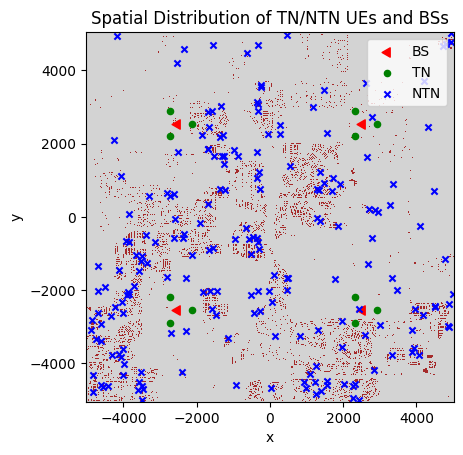

In [5]:
# SceneConfig.compute_positions(
#     ntn_rx=ntn_rx,
#     tn_rx=tn_rx,
#     azimuth=azimuth,
#     elevation=elevation,
#     centerBS=True,
#     bs_grid=(bs_row, bs_col),
#     bs_boundary=3000,
#     tn_building_ratio="sector",   # 0.5 -> 随机且50%在building
#     # tn_building_ratio="0.6",   # 0.5 -> 随机且50%在building
#     tn_distance=400,
#     ntn_building_ratio=0.7,
#     plot_grid=True,
#     plot_bs=True,
#     plot_tn=True,
#     plot_ntn=True
# )


SceneConfig.compute_positions(
    ntn_rx=ntn_rx,
    tn_rx=tn_rx,
    azimuth=azimuth,
    elevation=elevation,
    centerBS=False,
    bs_grid=(bs_row, bs_col),
    bs_boundary=2500,
    tn_building_ratio="sector",   
    # tn_building_ratio="0.6",   # 0.5 -> 随机且50%在building
    tn_distance=400,
    ntn_building_ratio=0.7,
    plot_grid=True,
    plot_bs=True,
    plot_tn=True,
    plot_ntn=True
)



tn_pos = SceneConfig.tn_pos
tx_pos = SceneConfig.tx_pos
rx_ntn_pos = SceneConfig.rx_ntn_pos


Run Simu

In [6]:
SceneConfig.compute_paths(
    nsect=nsect,
    fc=fc,
    tx_rows=tx_antenna_rows,
    tx_cols=tx_antenna_cols,
    tn_rx_rows=tn_rx_antenna_rows,
    tn_rx_cols=tn_rx_antenna_cols,
    max_depth=0,
    bandwidth=100e6,
    tx_power_dbm=30,
    sector_yaw_offset_rad=tx_sector_yaw_offset_rad,
    sector_pitch_rad=tx_sector_pitch_rad,
    sector_roll_rad=tx_sector_roll_rad

)
tn_bs_index = SceneConfig.tn_bs_index
tn_sector_index = SceneConfig.tn_sector_index
cir_tn = SceneConfig.a_tn
cir_ntn = SceneConfig.a_ntn

In [7]:
import numpy as np
import matplotlib.pyplot as plt


def _to_np(x):
    return x.numpy() if hasattr(x, "numpy") else np.asarray(x)


def _canonical_rx_tx_paths(arr, num_tx):
    # -> [num_rx, num_tx, num_paths_flat]
    a = np.squeeze(_to_np(arr))
    if a.ndim < 2:
        raise ValueError(f"Need >=2 dims for [rx,tx], got {a.shape}")
    tx_axes = [i for i, s in enumerate(a.shape) if s == num_tx]
    if not tx_axes:
        raise ValueError(f"Cannot find tx-axis size={num_tx} in {a.shape}")
    tx_axis = tx_axes[1] if (tx_axes[0] == 0 and len(tx_axes) > 1) else tx_axes[0]
    a = np.moveaxis(a, [0, tx_axis], [0, 1])
    return a.reshape(a.shape[0], a.shape[1], -1)


def _pair_and_path_power(cir, num_tx, num_paths):
    # Keep singleton dims (num_paths can be 1)
    h = _to_np(cir)
    tx_axes = [i for i, s in enumerate(h.shape) if s == num_tx]
    if not tx_axes:
        raise ValueError(f"Cannot find tx-axis size={num_tx} in cir shape={h.shape}")
    tx_axis = tx_axes[1] if (tx_axes[0] == 0 and len(tx_axes) > 1) else tx_axes[0]

    h_rt = np.moveaxis(h, [0, tx_axis], [0, 1])  # [rx, tx, ...]
    pwr = np.abs(h_rt) ** 2
    pair_power = pwr.sum(axis=tuple(range(2, pwr.ndim)))

    rest = h_rt.shape[2:]
    path_cands = [i for i, s in enumerate(rest) if s == num_paths]
    if not path_cands:
        if num_paths == 1:
            # Fallback: path axis collapsed upstream, treat as single-path
            return pair_power, pair_power[..., None]
        raise ValueError(f"Cannot align path axis: angle_paths={num_paths}, cir_rest={rest}")

    # If multiple singleton candidates, avoid last axis (often time=1) when possible
    pick = path_cands[-1]
    if len(path_cands) > 1 and pick == len(rest) - 1:
        pick = path_cands[-2]

    path_axis = 2 + pick
    sum_axes = tuple(ax for ax in range(2, h_rt.ndim) if ax != path_axis)
    path_power = pwr.sum(axis=sum_axes)
    return pair_power, path_power


# ===== Common config =====
nsect_eff = int(getattr(SceneConfig, "nsect", nsect))
nbs_eff = int(getattr(SceneConfig, "nbs", 1))
num_tx_total = int(nbs_eff * nsect_eff)
if "sionna_phi_is_global" not in globals():
    sionna_phi_is_global = True
if "theta_display_mode" not in globals():
    theta_display_mode = "elevation"  # or "zenith"
theta_mode = str(theta_display_mode).strip().lower()
if theta_mode not in ("zenith", "elevation"):
    raise ValueError(f"theta_display_mode must be 'zenith' or 'elevation', got {theta_display_mode}")
theta_name = "elev" if theta_mode == "elevation" else "theta"
def _theta_show(theta_zenith_deg):
    arr = np.asarray(theta_zenith_deg, dtype=float)
    return 90.0 - arr if theta_mode == "elevation" else arr
angle_eps_deg = 1e-9
channel_eps = 1e-18


# ===== NTN: keep (angle!=0) & (channel!=0), then pick strongest path =====
paths_ntn = SceneConfig.paths_ntn
if not hasattr(paths_ntn, "phi_t"):
    raise AttributeError("paths_ntn.phi_t not found in your Sionna version")

phi_probe = np.squeeze(_to_np(paths_ntn.phi_t))
if num_tx_total not in phi_probe.shape:
    nb_guess = int(nbs * nsect)
    if nb_guess in phi_probe.shape:
        num_tx_total = nb_guess
    elif nsect_eff in phi_probe.shape:
        num_tx_total = nsect_eff
    elif phi_probe.ndim >= 2:
        num_tx_total = int(phi_probe.shape[1])

print(
    f"num_tx_total used={num_tx_total}, SceneConfig.nbs={nbs_eff}, "
    f"SceneConfig.nsect={nsect_eff}, phi_t raw shape={phi_probe.shape}"
)

phi_t = _canonical_rx_tx_paths(paths_ntn.phi_t, num_tx_total)
theta_t = _canonical_rx_tx_paths(paths_ntn.theta_t, num_tx_total)
phi_t_raw_deg = np.mod(np.rad2deg(phi_t), 360.0)
theta_t_deg = np.rad2deg(theta_t)
tx_sector_map = sector_index_from_tx_index(np.arange(num_tx_total), nsect_eff)
if sionna_phi_is_global:
    phi_t_deg = phi_t_raw_deg
else:
    phi_t_deg = sector_local_aod_to_global(
        phi_t_raw_deg,
        sector_index=np.broadcast_to(tx_sector_map[None, :, None], phi_t_raw_deg.shape),
        nsect=nsect_eff,
    )
print("Sionna phi convention:", "global" if sionna_phi_is_global else "sector-local->global")

pair_power_ntn, path_power_ntn = _pair_and_path_power(cir_ntn, num_tx_total, phi_t_deg.shape[2])
angle_nonzero_pair_mask = np.any((np.abs(phi_t_deg) > angle_eps_deg) | (np.abs(theta_t_deg) > angle_eps_deg), axis=2)
channel_nonzero_pair_mask = pair_power_ntn > channel_eps
valid_pair_mask = angle_nonzero_pair_mask & channel_nonzero_pair_mask

ntn_rx_tx_pairs_angle_nonzero = np.argwhere(angle_nonzero_pair_mask)
ntn_rx_tx_pairs_channel_nonzero = np.argwhere(channel_nonzero_pair_mask)
ntn_rx_tx_pairs_valid = np.argwhere(valid_pair_mask)

print("rx-tx pairs with non-zero angle:", ntn_rx_tx_pairs_angle_nonzero.shape[0])
print("rx-tx pairs with non-zero channel:", ntn_rx_tx_pairs_channel_nonzero.shape[0])
print("rx-tx pairs kept by BOTH:", ntn_rx_tx_pairs_valid.shape[0])
print("angle-only pairs:", np.argwhere(angle_nonzero_pair_mask & (~channel_nonzero_pair_mask)).shape[0])
print("channel-only pairs:", np.argwhere((~angle_nonzero_pair_mask) & channel_nonzero_pair_mask).shape[0])

if ntn_rx_tx_pairs_valid.size:
    rx_idx_valid = ntn_rx_tx_pairs_valid[:, 0]
    t_idx_valid = ntn_rx_tx_pairs_valid[:, 1]
    pair_best_path = np.argmax(path_power_ntn[rx_idx_valid, t_idx_valid, :], axis=1)
    pair_phi_t_deg = phi_t_deg[rx_idx_valid, t_idx_valid, pair_best_path]
    pair_theta_t_deg = theta_t_deg[rx_idx_valid, t_idx_valid, pair_best_path]
    pair_bs_idx = t_idx_valid // nsect_eff
    pair_sector_idx = t_idx_valid % nsect_eff
else:
    rx_idx_valid = np.empty((0,), dtype=int)
    t_idx_valid = np.empty((0,), dtype=int)
    pair_best_path = np.empty((0,), dtype=int)
    pair_phi_t_deg = np.empty((0,), dtype=float)
    pair_theta_t_deg = np.empty((0,), dtype=float)
    pair_bs_idx = np.empty((0,), dtype=int)
    pair_sector_idx = np.empty((0,), dtype=int)

ntn_pair_rx_idx_keep = rx_idx_valid
ntn_pair_t_keep = t_idx_valid
ntn_pair_bs_keep = pair_bs_idx
ntn_pair_sector_keep = pair_sector_idx
ntn_pair_path_keep = pair_best_path
ntn_pair_phi_t_deg_keep = pair_phi_t_deg
ntn_pair_theta_t_deg_keep = pair_theta_t_deg

phi_t_ntn_deg = phi_t_deg
theta_t_ntn_deg = theta_t_deg

print(f"\nFirst 20 kept NTN pairs (rx, t, bs, sec, phi_t, {theta_name}):")
for i in range(min(20, len(ntn_pair_rx_idx_keep))):
    theta_show_i = float(_theta_show(ntn_pair_theta_t_deg_keep[i]))
    print(
        f"pair[{i:2d}] rx={int(ntn_pair_rx_idx_keep[i]):3d}, t={int(ntn_pair_t_keep[i]):2d}, "
        f"(bs={int(ntn_pair_bs_keep[i])}, sec={int(ntn_pair_sector_keep[i])}), "
        f"phi_t={float(ntn_pair_phi_t_deg_keep[i]):7.2f} deg, "
        f"{theta_name}={theta_show_i:7.2f} deg"
    )


# ===== TN: for each TN, read serving (bs,sector) angle on strongest path =====
paths_tn = SceneConfig.paths_tn
if not hasattr(paths_tn, "phi_t"):
    raise AttributeError("paths_tn.phi_t not found in your Sionna version")

phi_tn = _canonical_rx_tx_paths(paths_tn.phi_t, num_tx_total)
theta_tn = _canonical_rx_tx_paths(paths_tn.theta_t, num_tx_total)
phi_tn_raw_deg = np.mod(np.rad2deg(phi_tn), 360.0)
theta_t_tn_deg = np.rad2deg(theta_tn)
if sionna_phi_is_global:
    phi_t_tn_deg = phi_tn_raw_deg
else:
    phi_t_tn_deg = sector_local_aod_to_global(
        phi_tn_raw_deg,
        sector_index=np.broadcast_to(tx_sector_map[None, :, None], phi_tn_raw_deg.shape),
        nsect=nsect_eff,
    )

pair_power_tn, path_power_tn = _pair_and_path_power(cir_tn, num_tx_total, phi_t_tn_deg.shape[2])

tn_rx_all = np.arange(tn_pos.shape[0], dtype=int)
tn_t_all = tn_bs_index.astype(int) * nsect_eff + tn_sector_index.astype(int)
tn_in_range = (tn_t_all >= 0) & (tn_t_all < num_tx_total)

tn_rx = tn_rx_all[tn_in_range]
tn_t = tn_t_all[tn_in_range]
tn_bs = tn_bs_index.astype(int)[tn_in_range]
tn_sec = tn_sector_index.astype(int)[tn_in_range]

if tn_rx.size:
    tn_channel_ok = pair_power_tn[tn_rx, tn_t] > channel_eps
    tn_angle_ok = np.any(
        (np.abs(phi_t_tn_deg[tn_rx, tn_t, :]) > angle_eps_deg)
        | (np.abs(theta_t_tn_deg[tn_rx, tn_t, :]) > angle_eps_deg),
        axis=1,
    )
    tn_valid = tn_channel_ok & tn_angle_ok

    tn_best_path_all = np.argmax(path_power_tn[tn_rx, tn_t, :], axis=1)
    tn_phi_all = phi_t_tn_deg[tn_rx, tn_t, tn_best_path_all]
    tn_theta_all = theta_t_tn_deg[tn_rx, tn_t, tn_best_path_all]

    tn_pair_rx_idx_keep = tn_rx[tn_valid]
    tn_pair_t_keep = tn_t[tn_valid]
    tn_pair_bs_keep = tn_bs[tn_valid]
    tn_pair_sector_keep = tn_sec[tn_valid]
    tn_pair_path_keep = tn_best_path_all[tn_valid]
    tn_pair_phi_t_deg_keep = tn_phi_all[tn_valid]
    tn_pair_theta_t_deg_keep = tn_theta_all[tn_valid]
else:
    tn_pair_rx_idx_keep = np.empty((0,), dtype=int)
    tn_pair_t_keep = np.empty((0,), dtype=int)
    tn_pair_bs_keep = np.empty((0,), dtype=int)
    tn_pair_sector_keep = np.empty((0,), dtype=int)
    tn_pair_path_keep = np.empty((0,), dtype=int)
    tn_pair_phi_t_deg_keep = np.empty((0,), dtype=float)
    tn_pair_theta_t_deg_keep = np.empty((0,), dtype=float)

print("\nTN kept links:", len(tn_pair_rx_idx_keep))
print(f"First 20 TN links (rx, t, bs, sec, phi_t, {theta_name}):")
for i in range(min(20, len(tn_pair_rx_idx_keep))):
    theta_show_i = float(_theta_show(tn_pair_theta_t_deg_keep[i]))
    print(
        f"tn[{i:2d}] rx={int(tn_pair_rx_idx_keep[i]):3d}, t={int(tn_pair_t_keep[i]):2d}, "
        f"(bs={int(tn_pair_bs_keep[i])}, sec={int(tn_pair_sector_keep[i])}), "
        f"phi_t={float(tn_pair_phi_t_deg_keep[i]):7.2f} deg, "
        f"{theta_name}={theta_show_i:7.2f} deg"
    )




num_tx_total used=12, SceneConfig.nbs=4, SceneConfig.nsect=3, phi_t raw shape=(200, 12)
Sionna phi convention: global
rx-tx pairs with non-zero angle: 1134
rx-tx pairs with non-zero channel: 1087
rx-tx pairs kept by BOTH: 1087
angle-only pairs: 47
channel-only pairs: 0

First 20 kept NTN pairs (rx, t, bs, sec, phi_t, elev):
pair[ 0] rx=  0, t= 3, (bs=1, sec=0), phi_t= 132.37 deg, elev=  -1.20 deg
pair[ 1] rx=  0, t= 4, (bs=1, sec=1), phi_t= 132.37 deg, elev=  -1.20 deg
pair[ 2] rx=  0, t= 5, (bs=1, sec=2), phi_t= 132.37 deg, elev=  -1.20 deg
pair[ 3] rx=  0, t= 6, (bs=2, sec=0), phi_t= 335.49 deg, elev=  -3.49 deg
pair[ 4] rx=  0, t= 7, (bs=2, sec=1), phi_t= 335.49 deg, elev=  -3.49 deg
pair[ 5] rx=  0, t= 8, (bs=2, sec=2), phi_t= 335.49 deg, elev=  -3.49 deg
pair[ 6] rx=  2, t= 3, (bs=1, sec=0), phi_t= 147.66 deg, elev=  -1.92 deg
pair[ 7] rx=  2, t= 4, (bs=1, sec=1), phi_t= 147.66 deg, elev=  -1.92 deg
pair[ 8] rx=  2, t= 5, (bs=1, sec=2), phi_t= 147.66 deg, elev=  -1.92 deg
pair[ 9]

In [8]:
from scipy.stats import chi2
# --- Params for post-processing ---
EkT = -174    # Noise energy in dBm/Hz
B = 100e6
Tx_power_dbm = 30
Tx_power = 10 ** ((Tx_power_dbm - 30) / 10)
Tx_power_handheld_dbm = 23 # dbm
Tx_power_handheld = 10 ** ((Tx_power_handheld_dbm - 30) / 10)

NF = 7
NF_vsat = 3
NF_bs = 2
N0_dBm = EkT + 10 * np.log10(B) + NF
N0 = 10 ** ((N0_dBm - 30) / 10)
N0_vsat = 10 ** ((EkT + 10 * np.log10(B) + NF_vsat - 30) / 10)
N0_bs = 10 ** ((EkT + 10 * np.log10(B) + NF_bs - 30) / 10)

preamble_time = 20e-6
N0_sigma = N0_vsat / Tx_power / preamble_time
N0_sigma_handheld =  10 ** ((EkT+NF_bs - 30) / 10) /Tx_power_handheld/preamble_time
lambda_ranges = [0, 1e1, 1e3, 1e5]

snr_threshold = -6
inr_threshold = -6
h_ntn_th = np.sqrt(10**(inr_threshold/10)*N0_bs*tx_antennas /Tx_power)
h_tn_th = np.sqrt(10**(snr_threshold/10) * N0_bs * tx_antennas / Tx_power)
Threshold_peft = 10*np.log10(np.abs(h_tn_th)**2)
p_fa = 1/B
pfa_treshold =  chi2.ppf(1 - p_fa, 2 * tx_antennas) / 2  # t = Z/2
h_ntn_pfa_th =np.sqrt(pfa_treshold*N0_sigma)
h_tn_pfa_th =np.sqrt(pfa_treshold*N0_sigma_handheld)
Threshold = 10*np.log10(np.abs(h_ntn_pfa_th)**2)
Threshold_handheld = 10*np.log10(np.abs(h_tn_pfa_th)**2)

print(f"h_ntn_snr_th (from SNR threshold): {h_ntn_th:.4e}")
print(f"p_fa (false alarm rate): {p_fa:.2e}")
print(f"pfa_treshold(t) (false alarm rate): {pfa_treshold}")
print(f"h_ntn_pfa_th (from chi² Pfa threshold): {h_ntn_pfa_th}")
print(f"h_ntn_pfa_th (in dB): {Threshold }")
print(f"h_tn_pfa_th (in dB): {Threshold_handheld }")
print(f"Threshold_peft (in dB): {Threshold_peft }")





# --- MUSIC detection params (NTN) ---
music_num_sources = None
music_threshold = 3.0
music_covariance_mode = "sample"     # "analytic" or "sample"
music_num_snapshots = 200
music_noise_var = N0_bs / Tx_power
music_rng_seed = 7
music_source_estimation = "mdl"      # "mdl" or "energy"
music_energy_ratio = 0.95
music_reduce_ntn_ant = "max"         # "max" or "mean"
music_user_powers = None

# --- Sionna angle convention handling ---
# In your setup, Sionna AOD is treated as global azimuth directly.
# Set False only if you confirm phi_t is sector-local.
sionna_phi_is_global = True
# theta display mode: "zenith" (0=+z) or "elevation" (0=horizontal)
theta_display_mode = "elevation"

# --- MUSIC hat-angle / geometry debug params ---
# channel-mode candidates: "raw" | "conj" | "auto"
music_hat_channel_mode = "conj"
# true-reference for auto selection scoring: "aod" | "aoa_reverse"
music_ref_mode_for_auto = "aod"
# minimum matched pairs required for candidate scoring
music_auto_mode_min_pairs = 1

# include BS sector yaw/pitch/roll in steering
music_use_sector_orientation = True
music_sector_pitch_rad = float(globals().get("tx_sector_pitch_rad", -0.174533))
music_sector_roll_rad = float(globals().get("tx_sector_roll_rad", 0.0))
music_rotation_order = "zyx"
print(f"MUSIC sector orientation uses: pitch={music_sector_pitch_rad:.6f} rad, roll={music_sector_roll_rad:.6f} rad")

# manifold candidates:
# - fixed: e.g. "yz:+1"
# - auto: use list in music_manifold_auto_list
music_manifold_mode = "auto"
music_manifold_auto_list = ["yz:+1", "yz:-1", "xz:+1", "xz:-1"]

# steering vector flatten order candidates for array indexing
# "auto" -> try list below; otherwise use "C" or "F"
music_flatten_mode = "F"  # Sionna PlanarArray is column-first
music_flatten_mode_list = ["C", "F"]

# channel-to-steering matching mode
# "complex" uses full complex vector; "phase_only" ignores amplitude
# "auto" -> try list below
music_scan_mode = "auto"
music_scan_mode_list = ["complex", "phase_only"]

# azimuth output offset candidates (deg) for convention mismatch correction
# "auto" -> try list below; otherwise use numeric scalar (e.g., 90.0)
music_phi_offset_mode = "auto"
music_phi_offset_list = [0.0, 90.0, 180.0, 270.0]

# sector forward-halfspace constraint in peak search
music_sector_forward_only = True
music_sector_forward_cos_min = 0.0

# ===== Post-processing (beamforming / SNR / INR) =====

h_tn_all = collapse_cir_to_narrowband(cir_tn)
h_ntn_all = collapse_cir_to_narrowband(cir_ntn)

interfered_ntn = np.count_nonzero(np.any(h_ntn_all != 0, axis=(2, 3)))





h_ntn_snr_th (from SNR threshold): 3.1849e-06
p_fa (false alarm rate): 1.00e-08
pfa_treshold(t) (false alarm rate): 119.48150869313969
h_ntn_pfa_th (from chi² Pfa threshold): 0.0021783885773940287
h_ntn_pfa_th (in dB): -53.23729297860375
h_tn_pfa_th (in dB): -127.23729297860373
Threshold_peft (in dB): -109.93820026016111
MUSIC sector orientation uses: pitch=-0.087266 rad, roll=0.000000 rad


In [9]:
# ===== NTN MUSIC angle display (standard fixed-convention MUSIC) =====
import numpy as np
import importlib
import ntn_music_detection as _nmd
importlib.reload(_nmd)
run_music_standard_pipeline = _nmd.run_music_standard_pipeline

# Build true NTN map from strongest-path pairs extracted earlier (for final evaluation only)
ntn_true_map = build_true_pair_map(
    ntn_pair_rx_idx_keep,
    ntn_pair_t_keep,
    ntn_pair_phi_t_deg_keep,
    ntn_pair_theta_t_deg_keep,
    ntn_pair_bs_keep,
    ntn_pair_sector_keep,
)

nsect_eff_ntn = int(globals().get("nsect_eff", getattr(SceneConfig, "nsect", nsect)))

# Standard fixed conventions aligned with Sionna setup:
# - channel_mode="conj" (uplink/downlink conjugate convention)
# - manifold_label="yz:+1" (panel boresight +x at yaw=0)
# - flatten_order="F" (column-first flattening for PlanarArray indexing)
# - scan_mode="complex" (standard complex steering match)
# - phi_offset_deg=0.0 (no empirical azimuth compensation)
music_std_channel_mode = "conj"
music_std_manifold_label = "yz:+1"
music_std_flatten_order = "F"
music_std_scan_mode = "complex"
music_std_phi_offset_deg = 0.0
music_std_phi_mirror_about_sector = False  # now fixed in steering horizontal sign
music_std_horizontal_sign = -1

ntn_music_out = run_music_standard_pipeline(
    h_ntn_all,
    tx_rows=int(tx_antenna_rows),
    tx_cols=int(tx_antenna_cols),
    nsect=nsect_eff_ntn,
    pair_keys=None,  # detection mode for NTN
    detect_num_sources=music_num_sources,
    detect_threshold=music_threshold,
    detect_user_powers=music_user_powers,
    detect_noise_var=music_noise_var,
    detect_covariance_mode=music_covariance_mode,
    detect_num_snapshots=music_num_snapshots,
    detect_rng_seed=music_rng_seed,
    detect_source_estimation=music_source_estimation,
    detect_energy_ratio=music_energy_ratio,
    detect_reduce_rx_ant=music_reduce_ntn_ant,
    channel_mode=music_std_channel_mode,
    manifold_label=music_std_manifold_label,
    flatten_order=music_std_flatten_order,
    scan_mode=music_std_scan_mode,
    phi_offset_deg=music_std_phi_offset_deg,
    phi_mirror_about_sector=music_std_phi_mirror_about_sector,
    steering_horizontal_sign=music_std_horizontal_sign,
    use_sector_orientation=music_use_sector_orientation,
    sector_pitch_rad=music_sector_pitch_rad,
    sector_roll_rad=music_sector_roll_rad,
    rotation_order=music_rotation_order,
    sector_forward_only=music_sector_forward_only,
    sector_forward_cos_min=music_sector_forward_cos_min,
    phi_grid_deg=globals().get("music_phi_grid_deg", np.arange(0.0, 360.0, 1.0)),
    theta_grid_deg=globals().get("music_theta_grid_deg", np.arange(0.0, 181.0, 1.0)),
)

ntn_music_pair_hat = ntn_music_out["pair_hat"]
ntn_det_pairs = sorted(ntn_music_pair_hat.keys(), key=lambda k: (k[1], k[0]))

ntn_music_pair_rx_idx_keep = np.asarray(ntn_music_out["pair_rx_idx"], dtype=int)
ntn_music_pair_t_keep = np.asarray(ntn_music_out["pair_t_idx"], dtype=int)
ntn_music_pair_bs_keep = np.asarray(ntn_music_out["pair_bs_idx"], dtype=int)
ntn_music_pair_sector_keep = np.asarray(ntn_music_out["pair_sector_idx"], dtype=int)
ntn_music_pair_phi_t_deg_keep = np.asarray(ntn_music_out["pair_phi_hat_deg"], dtype=float)
ntn_music_pair_theta_t_deg_keep = np.asarray(ntn_music_out["pair_theta_hat_deg"], dtype=float)
ntn_music_pair_u_hat = np.asarray(ntn_music_out["pair_u_hat"], dtype=np.complex128)
ntn_music_pair_alpha_hat = np.asarray(ntn_music_out["pair_alpha_hat_raw"], dtype=np.complex128)
ntn_h_hat_all = np.asarray(ntn_music_out["h_hat_all"], dtype=np.complex128)
ntn_u_by_sector = {
    int(s): ntn_music_pair_u_hat[ntn_music_pair_sector_keep == int(s)]
    for s in np.unique(ntn_music_pair_sector_keep)
}

# NTN path/detection stats + detected NTN positions for plotting
if "h_ntn_all" in globals():
    ntn_has_path_mask = np.any(np.abs(np.asarray(h_ntn_all)) > 0.0, axis=(1, 2, 3))
else:
    ntn_has_path_mask = np.zeros((0,), dtype=bool)

if ntn_has_path_mask.size == 0 and len(ntn_true_map) > 0:
    max_rx = max([int(k[0]) for k in ntn_true_map.keys()])
    ntn_has_path_mask = np.zeros((max_rx + 1,), dtype=bool)
    ntn_has_path_mask[[int(k[0]) for k in ntn_true_map.keys()]] = True

ntn_detected_rx_idx = np.asarray(
    ntn_music_out.get("detected_rx_indices_unique", np.unique(ntn_music_pair_rx_idx_keep)),
    dtype=int,
)
ntn_detected_rx_idx = ntn_detected_rx_idx[(ntn_detected_rx_idx >= 0)]

if ntn_has_path_mask.size > 0:
    valid_det = ntn_detected_rx_idx[ntn_detected_rx_idx < ntn_has_path_mask.size]
    ntn_detected_has_path_count = int(np.count_nonzero(ntn_has_path_mask[valid_det]))
else:
    ntn_detected_has_path_count = int(ntn_detected_rx_idx.size)

if "rx_ntn_pos" in globals():
    _ntn_pos_all = np.asarray(rx_ntn_pos)
elif "SceneConfig" in globals() and hasattr(SceneConfig, "rx_ntn_pos") and SceneConfig.rx_ntn_pos is not None:
    _ntn_pos_all = np.asarray(SceneConfig.rx_ntn_pos)
else:
    _ntn_pos_all = np.empty((0, 3), dtype=float)

if _ntn_pos_all.shape[0] > 0:
    _idx_keep = ntn_detected_rx_idx[ntn_detected_rx_idx < _ntn_pos_all.shape[0]]
    left_ntn_pos = _ntn_pos_all[_idx_keep]
else:
    left_ntn_pos = np.empty((0, 3), dtype=float)

print("NTN standard MUSIC config:", f"{music_std_channel_mode}|{music_std_manifold_label}|{music_std_flatten_order}|{music_std_scan_mode}|{music_std_phi_offset_deg:.1f}|mirror={music_std_phi_mirror_about_sector}|hsign={music_std_horizontal_sign}")
print("NTN with path count:", int(np.count_nonzero(ntn_has_path_mask)) if ntn_has_path_mask.size > 0 else 0)
print("NTN detected by MUSIC count:", int(ntn_detected_rx_idx.size))
print("NTN detected & has-path count:", int(ntn_detected_has_path_count))
print("left_ntn_pos shape:", left_ntn_pos.shape)
print("NTN h_hat_all shape:", ntn_h_hat_all.shape)
if ntn_music_pair_alpha_hat.size > 0:
    print("NTN |alpha_hat| mean:", float(np.mean(np.abs(ntn_music_pair_alpha_hat))))
if np.asarray(ntn_music_out["num_sources_record"]).size > 0 and np.any(np.asarray(ntn_music_out["num_sources_record"]) >= 0):
    v = np.asarray(ntn_music_out["num_sources_record"], dtype=int)
    print("NTN MUSIC estimated K (mean):", float(np.mean(v[v >= 0])))

print("\nNTN detected pairs (HAT):", len(ntn_det_pairs))
theta_name = "elev" if str(theta_display_mode).lower() == "elevation" else "theta"
print(f"format: pair(rx,t,bs,sec) | trueAOD_global(phi,{theta_name}) | hat_global(phi,{theta_name})")

for i, (rx, t) in enumerate(ntn_det_pairs):
    rec = ntn_music_pair_hat[(rx, t)]
    phi_hat = float(rec["phi_hat_deg"])
    theta_hat = float(rec["theta_hat_deg"])

    if str(theta_display_mode).lower() == "elevation":
        theta_hat_show = float(zenith_to_elevation_deg(np.array([theta_hat]))[0])
    else:
        theta_hat_show = float(theta_hat)

    if (rx, t) in ntn_true_map:
        phi_true, theta_true, _bs_t, _sec_t = ntn_true_map[(rx, t)]
        if str(theta_display_mode).lower() == "elevation":
            theta_true_show = float(zenith_to_elevation_deg(np.array([theta_true]))[0])
        else:
            theta_true_show = float(theta_true)
        true_text = f"trueAOD_global(phi={float(phi_true):7.2f}, {theta_name}={theta_true_show:7.2f})"
    else:
        true_text = f"trueAOD_global(phi={float('nan'):7.2f}, {theta_name}={float('nan'):7.2f})"

    print(
        f"pair[{i:3d}] (rx={int(rx):3d}, t={int(t):2d}, bs={int(rec['bs'])}, sec={int(rec['sec'])}) | "
        f"{true_text} | "
        f"hat_global(phi={phi_hat:7.2f}, {theta_name}={theta_hat_show:7.2f})"
    )

matched_pairs = [k for k in ntn_det_pairs if k in ntn_true_map]
if len(matched_pairs) > 0:
    phi_true_match = np.array([ntn_true_map[k][0] for k in matched_pairs], dtype=float)
    theta_true_match = np.array([ntn_true_map[k][1] for k in matched_pairs], dtype=float)
    phi_hat_match = np.array([ntn_music_pair_hat[k]["phi_hat_deg"] for k in matched_pairs], dtype=float)
    theta_hat_match = np.array([ntn_music_pair_hat[k]["theta_hat_deg"] for k in matched_pairs], dtype=float)

    if str(theta_display_mode).lower() == "elevation":
        theta_true_metric = zenith_to_elevation_deg(theta_true_match)
        theta_hat_metric = zenith_to_elevation_deg(theta_hat_match)
        theta_metric_name = "elev"
    else:
        theta_true_metric = theta_true_match
        theta_hat_metric = theta_hat_match
        theta_metric_name = "theta"

    ntn_metrics_aod = angle_error_metrics(
        phi_true_match,
        theta_true_metric,
        phi_hat_match,
        theta_hat_metric,
        reference_mode="aod",
    )

    print("\nNTN Angle Error Summary on matched detected pairs:")
    print(
        "  ref=AOD(global) : "
        f"N={int(ntn_metrics_aod['count'])}, "
        f"phi_MAE={ntn_metrics_aod['phi_mae_deg']:.2f} deg, "
        f"{theta_metric_name}_MAE={ntn_metrics_aod['theta_mae_deg']:.2f} deg"
    )
else:
    print("\nNTN Angle Error Summary: no matched pairs between detected links and Sionna true map.")


NTN standard MUSIC config: conj|yz:+1|F|complex|0.0|mirror=False|hsign=-1
NTN with path count: 165
NTN detected by MUSIC count: 126
NTN detected & has-path count: 126
left_ntn_pos shape: (126, 3)
NTN h_hat_all shape: (200, 1, 12, 64)
NTN |alpha_hat| mean: 1.9124931158937418e-06
NTN MUSIC estimated K (mean): 3.9166666666666665

NTN detected pairs (HAT): 223
format: pair(rx,t,bs,sec) | trueAOD_global(phi,elev) | hat_global(phi,elev)
pair[  0] (rx= 16, t= 0, bs=0, sec=0) | trueAOD_global(phi= 336.06, elev=  -0.24) | hat_global(phi= 336.00, elev=   0.00)
pair[  1] (rx= 23, t= 0, bs=0, sec=0) | trueAOD_global(phi= 343.11, elev=  -0.12) | hat_global(phi= 343.00, elev=   0.00)
pair[  2] (rx= 27, t= 0, bs=0, sec=0) | trueAOD_global(phi= 334.74, elev=  -0.33) | hat_global(phi= 335.00, elev=   0.00)
pair[  3] (rx= 36, t= 0, bs=0, sec=0) | trueAOD_global(phi= 333.39, elev=  -0.03) | hat_global(phi= 333.00, elev=   0.00)
pair[  4] (rx= 46, t= 0, bs=0, sec=0) | trueAOD_global(phi= 330.64, elev=  -0

In [10]:
# pair级结果
pair_hat = ntn_music_out["pair_hat"]                      # dict: key=(rx,t)
pair_rx = ntn_music_out["pair_rx_idx"]                    # (N,)
pair_t = ntn_music_out["pair_t_idx"]                      # (N,)
pair_sec = ntn_music_out["pair_sector_idx"]               # (N,)

pair_phi = ntn_music_out["pair_phi_hat_deg"]              # (N,)
pair_theta = ntn_music_out["pair_theta_hat_deg"]          # (N,)

pair_u = ntn_music_out["pair_u_hat"]                      # (N, tx_ant)
pair_alpha = ntn_music_out["pair_alpha_hat_raw"]          # (N,) complex
pair_h_hat = ntn_music_out["pair_h_hat_vec_raw"]          # (N, tx_ant) complex
h_hat_all = ntn_music_out["h_hat_all"]                    # (num_rx, num_rx_ant, num_tx, num_tx_ant)


In [11]:

# ===== h_ntn_hat vs h_ntn_all (detected NTN subset only) =====
import numpy as np

if "ntn_music_out" not in globals():
    raise RuntimeError("Run the NTN MUSIC cell first to get ntn_music_out.")
if "h_ntn_all" not in globals():
    raise RuntimeError("h_ntn_all not found. Run the post-processing prep cell first.")

EPS = 1e-12

h_ntn_all_np = np.asarray(h_ntn_all, dtype=np.complex128)
h_ntn_hat_all_np = np.asarray(ntn_music_out.get("h_hat_all", np.zeros_like(h_ntn_all_np)), dtype=np.complex128)

if h_ntn_hat_all_np.shape != h_ntn_all_np.shape:
    raise ValueError(f"Shape mismatch: h_ntn_hat_all{h_ntn_hat_all_np.shape} vs h_ntn_all{h_ntn_all_np.shape}")

# Detected NTN user indices from MUSIC
pair_rx = np.asarray(ntn_music_out.get("pair_rx_idx", []), dtype=int)
if pair_rx.size == 0:
    det_rx_idx = np.asarray(ntn_music_out.get("detected_rx_indices_unique", []), dtype=int)
else:
    det_rx_idx = np.unique(pair_rx)

det_rx_idx = det_rx_idx[(det_rx_idx >= 0) & (det_rx_idx < h_ntn_all_np.shape[0])]
det_rx_idx = np.unique(det_rx_idx)

if det_rx_idx.size == 0:
    print("No detected NTN users to compare.")
else:
    # Keep only detected NTN users: first dimension becomes detected count
    h_ntn = h_ntn_all_np[det_rx_idx, :, :, :]
    h_ntn_hat = h_ntn_hat_all_np[det_rx_idx, :, :, :]

    def _err_metrics(x_hat, x_true, eps=1e-12):
        xh = np.asarray(x_hat, dtype=np.complex128).reshape(-1)
        xt = np.asarray(x_true, dtype=np.complex128).reshape(-1)
        if xh.size == 0:
            return {
                "count": 0,
                "nrmse": np.nan,
                "cos_sim": np.nan,
                "mag_mae": np.nan,
                "power_ratio_db": np.nan,
            }
        e = xh - xt
        nrmse = np.linalg.norm(e) / (np.linalg.norm(xt) + eps)
        cos_sim = np.abs(np.vdot(xh, xt)) / (np.linalg.norm(xh) * np.linalg.norm(xt) + eps)
        mag_mae = np.mean(np.abs(np.abs(xh) - np.abs(xt)))
        p_hat = np.sum(np.abs(xh) ** 2)
        p_true = np.sum(np.abs(xt) ** 2)
        power_ratio_db = 10.0 * np.log10((p_hat + eps) / (p_true + eps))
        return {
            "count": int(xh.size),
            "nrmse": float(nrmse),
            "cos_sim": float(cos_sim),
            "mag_mae": float(mag_mae),
            "power_ratio_db": float(power_ratio_db),
        }

    met = _err_metrics(h_ntn_hat, h_ntn, eps=EPS)

    # Optional pair-level summary inside detected subset
    pair_t = np.asarray(ntn_music_out.get("pair_t_idx", []), dtype=int)
    if "pair_rx_ant_idx" in ntn_music_out:
        pair_ant = np.asarray(ntn_music_out.get("pair_rx_ant_idx", []), dtype=int)
    else:
        pair_ant = np.zeros((pair_rx.size,), dtype=int)

    valid = (
        (pair_rx >= 0) & (pair_rx < h_ntn_all_np.shape[0])
        & (pair_t >= 0) & (pair_t < h_ntn_all_np.shape[2])
        & (pair_ant >= 0) & (pair_ant < h_ntn_all_np.shape[1])
    )

    pair_rx_v = pair_rx[valid]
    pair_t_v = pair_t[valid]
    pair_ant_v = pair_ant[valid]

    pair_nrmse = []
    pair_cos = []
    for rx_i, ant_i, t_i in zip(pair_rx_v, pair_ant_v, pair_t_v):
        a = h_ntn_hat_all_np[int(rx_i), int(ant_i), int(t_i), :]
        b = h_ntn_all_np[int(rx_i), int(ant_i), int(t_i), :]
        pair_nrmse.append(np.linalg.norm(a - b) / (np.linalg.norm(b) + EPS))
        pair_cos.append(np.abs(np.vdot(a, b)) / (np.linalg.norm(a) * np.linalg.norm(b) + EPS))

    pair_nrmse = np.asarray(pair_nrmse, dtype=float)
    pair_cos = np.asarray(pair_cos, dtype=float)

    print("Detected NTN rx indices count:", int(det_rx_idx.size))
    print("det_rx_idx (first 20):", det_rx_idx[:20])
    print("h_ntn shape (detected subset):", h_ntn.shape)
    print("h_ntn_hat shape (detected subset):", h_ntn_hat.shape)

    print()
    print("[Detected-subset tensor metrics]")
    print(
        f"N={met['count']}, NRMSE={met['nrmse']:.4e}, "
        f"CosSim={met['cos_sim']:.6f}, |h| MAE={met['mag_mae']:.4e}, "
        f"PowerRatio={met['power_ratio_db']:.3f} dB"
    )

    if pair_nrmse.size > 0:
        print()
        print("[Detected pairs summary]")
        print(
            f"pairs={pair_nrmse.size}, "
            f"NRMSE mean/median={np.mean(pair_nrmse):.4e}/{np.median(pair_nrmse):.4e}, "
            f"CosSim mean/median={np.mean(pair_cos):.6f}/{np.median(pair_cos):.6f}"
        )


Detected NTN rx indices count: 126
det_rx_idx (first 20): [ 0  2  3  6  8 11 14 16 17 18 19 20 21 22 23 24 26 27 30 31]
h_ntn shape (detected subset): (126, 1, 12, 64)
h_ntn_hat shape (detected subset): (126, 1, 12, 64)

[Detected-subset tensor metrics]
N=96768, NRMSE=1.4054e-01, CosSim=0.989756, |h| MAE=8.5221e-09, PowerRatio=-0.087 dB

[Detected pairs summary]
pairs=223, NRMSE mean/median=4.3019e-02/4.7441e-02, CosSim mean/median=0.527439/0.591452


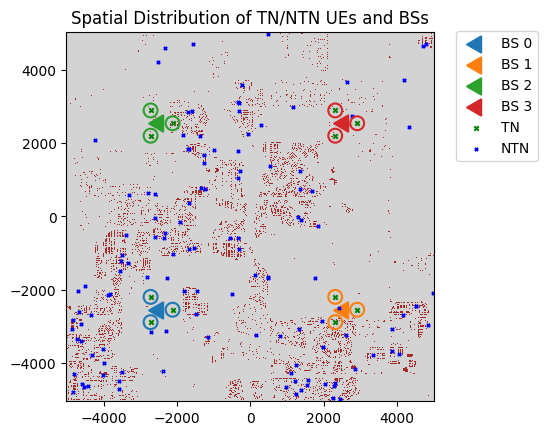

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# background
colors = ['lightgray', 'brown']
cmap_bg = ListedColormap(colors)

extent = SceneConfig.extent
point_type = SceneConfig.point_type

tn_bs_index = SceneConfig.tn_bs_index

plt.figure()
plt.imshow(point_type, cmap=cmap_bg, interpolation='nearest', extent=extent)


# BS colors: high-contrast palette
cmap_bs = plt.get_cmap("tab10")
n_bs = tx_pos.shape[0]
bs_colors = [cmap_bs(i % 10) for i in range(n_bs)]


# BS triangles (bigger and more visible)
bs_marker = (3, 0, -30)
for i in range(n_bs):
    plt.scatter(
        tx_pos[i, 0], tx_pos[i, 1],
        c=[bs_colors[i]],
        marker=bs_marker,
        s=180,           # bigger
        linewidths=1.5,  # thicker edge
        # edgecolors='k',  # black edge for contrast
        label=f"BS {i}"
    )


# TN points (same as compute_positions: green x)
plt.scatter(tn_pos[:, 0], tn_pos[:, 1], color='green', marker='x', s=10, label='TN')

# NTN points (same as compute_positions: blue x)
plt.scatter(left_ntn_pos[:, 0], left_ntn_pos[:, 1], color='blue', marker='x', s=5, label='NTN')

# Outer circles on TN, color matched to its BS
for i in range(tn_pos.shape[0]):
    bs_id = int(tn_bs_index[i])
    plt.scatter(
        tn_pos[i, 0], tn_pos[i, 1],
        edgecolors=bs_colors[bs_id], facecolors='none',
        marker='o', s=100, linewidths=1.5
    )

# plt.title('Spatial Distribution of TN/NTN and BSs')
plt.title('Spatial Distribution of TN/NTN UEs and BSs')

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.02), fontsize=10, frameon=True)

import os
# save_path = "/home/sj4025/my_project/ntn_int_nulling/map.png"
# os.makedirs(os.path.dirname(save_path), exist_ok=True)
# plt.savefig(save_path, dpi=300, format='png')
plt.show()


Different Lambda_

In [13]:
lambda_ranges = [0, 1e10, 1e11, 1e12]

eps = 1e-12  # avoid log10(0)
snr_list = []
h_ntn_dB_list = []
h_tn_dB_list = []

w_t_record = []
v_null_record = {l: [] for l in lambda_ranges}
v_null_t_index = {l: [] for l in lambda_ranges}

eigen_value_dict = {l: [] for l in lambda_ranges}
snr_nulling_dict = {l: [] for l in lambda_ranges}
snr_nulling_hat_dict = {l: [] for l in lambda_ranges}
snr_degration_dict = {l: [] for l in lambda_ranges}
inr_nulling_dict = {l: [] for l in lambda_ranges}
inr_nulling_hat_dict = {l: [] for l in lambda_ranges}

best_tx_list = []
w_t_grouped, w_r_grouped, h_grouped = {}, {}, {}

import importlib
import BeamformingCalc
if not hasattr(BeamformingCalc, "nulling_bf_music_noncoh"):
    importlib.reload(BeamformingCalc)
nulling_bf_music_noncoh = BeamformingCalc.nulling_bf_music_noncoh

if "ntn_music_out" not in globals():
    raise ValueError("ntn_music_out not found. Run NTN standard MUSIC cell first.")

num_ntn_rx = int(h_ntn_all.shape[0])
num_ntn_rx_ant = int(h_ntn_all.shape[1])
num_tx_total = int(h_ntn_all.shape[2])

music_pair_rx = np.asarray(ntn_music_out.get("pair_rx_idx", []), dtype=int)
music_pair_t = np.asarray(ntn_music_out.get("pair_t_idx", []), dtype=int)
music_pair_u = np.asarray(ntn_music_out.get("pair_u_hat", []), dtype=np.complex128)
music_pair_alpha_hat = np.asarray(ntn_music_out.get("pair_alpha_hat_raw", []), dtype=np.complex128)
if "pair_rx_ant_idx" in ntn_music_out:
    music_pair_rx_ant = np.asarray(ntn_music_out.get("pair_rx_ant_idx"), dtype=int)
else:
    music_pair_rx_ant = np.zeros((music_pair_rx.size,), dtype=int)

if music_pair_u.ndim == 1 and music_pair_u.size > 0:
    music_pair_u = music_pair_u.reshape(1, -1)
if music_pair_u.ndim != 2 and music_pair_u.size != 0:
    raise ValueError(f"ntn_music_out['pair_u_hat'] must be 2D, got shape={music_pair_u.shape}")

num_pairs = int(music_pair_rx.size)
if not (
    music_pair_t.size == num_pairs
    and music_pair_alpha_hat.size == num_pairs
    and music_pair_rx_ant.size == num_pairs
    and (music_pair_u.shape[0] == num_pairs if music_pair_u.size > 0 else num_pairs == 0)
):
    raise ValueError("Inconsistent ntn_music_out pair array lengths.")

music_pair_indices_by_t = {}
for idx in range(num_pairs):
    rx_i = int(music_pair_rx[idx])
    t_i = int(music_pair_t[idx])
    if rx_i < 0 or rx_i >= num_ntn_rx or t_i < 0 or t_i >= num_tx_total:
        continue
    music_pair_indices_by_t.setdefault(t_i, []).append(idx)

# Use one-to-one TN pairing (nearest BS + sector)
for r in range(tn_pos.shape[0]):
    t = int(tn_bs_index[r]) * nsect + int(tn_sector_index[r])
    h_tn = h_tn_all[r, :, t, :].T  # Transfer to ntx*nrx
    h_tn_norm = np.linalg.norm(h_tn, ord='fro')
    h_tn_dB = 10 * np.log10(np.maximum(h_tn_norm**2, eps))
    h_tn_dB_list.append(h_tn_dB.item())

    # Keep TN filtering unchanged
    if np.any(h_tn_norm > h_tn_th):
        w_t, w_r = svd_bf(h_tn, tx_antennas)
        snr = 10 * np.log10((np.abs(w_t.conj().T @ h_tn @ w_r)**2) * Tx_power / N0)

        best_tx_list.append(t)
        snr_list.append(snr.item())

        if t not in w_t_grouped:
            w_t_grouped[t], w_r_grouped[t], h_grouped[t] = [], [], []
        w_t_grouped[t].append(w_t)
        w_r_grouped[t].append(w_r)
        h_grouped[t].append(h_tn)

for t in w_t_grouped:
    w_t_grouped[t] = np.array(w_t_grouped[t])
    w_r_grouped[t] = np.array(w_r_grouped[t])
    h_grouped[t] = np.array(h_grouped[t])

if len(w_t_grouped) == 0:
    raise ValueError("No valid TN links after thresholding.")

min_count = min(len(w_t_grouped[t]) for t in w_t_grouped)

inr_list = []
ntn_kept_indices = []
mask_record = []

for m in range(min_count):
    valid_mask = np.zeros((num_ntn_rx,), dtype=bool)
    h_i_gain_sum = np.zeros((num_ntn_rx,), dtype=np.float64)
    h_i_null_gain_sum_dict = {l: np.zeros((num_ntn_rx,), dtype=np.float64) for l in lambda_ranges}
    h_i_null_gain_sum_hat_dict = {l: np.zeros((num_ntn_rx,), dtype=np.float64) for l in lambda_ranges}

    for t in range(nbs * nsect):
        if t not in w_t_grouped or len(w_t_grouped[t]) <= m:
            continue

        w_t = w_t_grouped[t][m]
        w_r = w_r_grouped[t][m]
        h = h_grouped[t][m]

        v_t = np.conj(w_t)
        w_t_record.append(v_t.copy())

        # True NTN channels for this TX sector (used for INR evaluation)
        h_i = np.array(h_ntn_all[:, :, t, :], copy=True)
        h_i_norms = np.linalg.norm(h_i, axis=2)
        h_ntn_dB = 10 * np.log10(np.maximum(h_i_norms**2, eps))
        h_ntn_dB_list.append(h_ntn_dB)

        pair_idx_t = np.asarray(music_pair_indices_by_t.get(int(t), []), dtype=int)
        if pair_idx_t.size > 0:
            rx_det = music_pair_rx[pair_idx_t]
            rx_det = rx_det[(rx_det >= 0) & (rx_det < num_ntn_rx)]
            rx_det = np.unique(rx_det)
        else:
            rx_det = np.empty((0,), dtype=int)

        # NTN filtering now follows MUSIC detections only
        valid_mask[rx_det] = True

        mask = np.ones((num_ntn_rx, num_ntn_rx_ant), dtype=bool)
        if rx_det.size > 0:
            mask[rx_det, :] = False
        mask_record.append(mask.copy())
        ntn_kept_indices.append(rx_det)

        h_i[mask] = 0.0 + 0.0j

        # Estimated channels from MUSIC output (if available)
        if "ntn_h_hat_all" in globals():
            h_i_hat = np.array(ntn_h_hat_all[:, :, t, :], copy=True)
            if h_i_hat.shape != h_i.shape:
                h_i_hat = np.array(h_i, copy=True)
        else:
            h_i_hat = np.array(h_i, copy=True)
        h_i_hat[mask] = 0.0 + 0.0j

        # Build MUSIC nulling term sum_i G_i u_i u_i^H for this TX
        if pair_idx_t.size > 0 and music_pair_u.size > 0:
            u_t = np.asarray(music_pair_u[pair_idx_t, :], dtype=np.complex128)
            alpha_hat_t = np.asarray(music_pair_alpha_hat[pair_idx_t], dtype=np.complex128)
            finite_u = np.all(np.isfinite(np.real(u_t)) & np.isfinite(np.imag(u_t)), axis=1)
            finite_alpha = np.isfinite(np.real(alpha_hat_t)) & np.isfinite(np.imag(alpha_hat_t))
            finite_rows = finite_u & finite_alpha

            if np.any(finite_rows):
                u_t = u_t[finite_rows]
                alpha_hat_t = alpha_hat_t[finite_rows]
                g_hat_t = np.abs(alpha_hat_t) ** 2
            else:
                u_t = np.empty((0, h.shape[0]), dtype=np.complex128)
                g_hat_t = np.empty((0,), dtype=np.float64)
        else:
            u_t = np.empty((0, h.shape[0]), dtype=np.complex128)
            g_hat_t = np.empty((0,), dtype=np.float64)

        h_i_gain = np.abs(np.sum(h_i @ w_t, axis=1).squeeze() / np.sqrt(max(h_i.shape[1], 1))) ** 2
        h_i_gain_sum += h_i_gain

        for lambda_ in lambda_ranges:
            v_null, Q_1, Q_2, max_eigen_value = nulling_bf_music_noncoh(h, w_r, u_t, g_hat_t, lambda_)
            v_null_hat, _, _, _ = nulling_bf_music_noncoh(h, w_r, u_t, g_hat_t, lambda_)

            v_null_t = np.conj(v_null)
            v_null_record[lambda_].append(v_null_t.copy())
            v_null_t_index[lambda_].append(t)

            eigen_value_dict[lambda_].append(float(max_eigen_value))

            snr_nulling = 10 * np.log10((np.abs(v_null.conj().T @ h @ w_r) ** 2) * Tx_power / N0)
            snr_nulling_hat = 10 * np.log10((np.abs(v_null_hat.conj().T @ h @ w_r) ** 2) * Tx_power / N0)

            snr_nulling_dict[lambda_].append(snr_nulling.item())
            snr_nulling_hat_dict[lambda_].append(snr_nulling_hat.item())

            snr_degration = 10 * np.log10((np.abs(w_t.conj().T @ h @ w_r) ** 2) / (np.abs(v_null_hat.conj().T @ h @ w_r) ** 2 + eps))
            snr_degration_dict[lambda_].append(snr_degration.item())

            h_i_null_gain = np.abs(np.sum(h_i @ v_null, axis=1).ravel() / np.sqrt(max(h_i.shape[1], 1))) ** 2
            h_i_null_gain_sum_dict[lambda_] += h_i_null_gain

            h_i_null_gain_hat = np.abs(np.sum(h_i_hat @ v_null_hat, axis=1).ravel() / np.sqrt(max(h_i_hat.shape[1], 1))) ** 2
            h_i_null_gain_sum_hat_dict[lambda_] += h_i_null_gain_hat

    inr = 10 * np.log10(np.maximum(h_i_gain_sum * Tx_power / N0, eps))
    inr_list.extend(inr[valid_mask])

    for lambda_ in lambda_ranges:
        inr_nulling = 10 * np.log10(np.maximum(h_i_null_gain_sum_dict[lambda_] * Tx_power / N0, eps))
        inr_nulling_dict[lambda_].extend(inr_nulling[valid_mask])

        inr_nulling_hat = 10 * np.log10(np.maximum(h_i_null_gain_sum_hat_dict[lambda_] * Tx_power / N0, eps))
        inr_nulling_hat_dict[lambda_].extend(inr_nulling_hat[valid_mask])

print("ntn_number_has_path_to BS:", interfered_ntn)
print("Used_tn:", min_count)

unique_ntn_kept_indices = np.unique(np.concatenate(ntn_kept_indices)) if ntn_kept_indices else np.array([], dtype=int)
if "rx_ntn_pos" in globals():
    _ntn_pos_all = np.asarray(rx_ntn_pos)
elif "SceneConfig" in globals() and hasattr(SceneConfig, "rx_ntn_pos") and SceneConfig.rx_ntn_pos is not None:
    _ntn_pos_all = np.asarray(SceneConfig.rx_ntn_pos)
else:
    _ntn_pos_all = np.empty((0, 3), dtype=float)

left_ntn_pos = _ntn_pos_all[unique_ntn_kept_indices] if unique_ntn_kept_indices.size and _ntn_pos_all.shape[0] > 0 else np.empty((0, 3))
print("detected ntn number:", int(unique_ntn_kept_indices.size))
print("left_ntn_pos shape:", left_ntn_pos.shape)

# Optional: save
save_dict = {
    "w_t_record": np.array(w_t_record),
    "ntn_pos": np.array(left_ntn_pos),
    "tn_pos": np.array(tn_pos),
}

for lambda_ in v_null_record:
    save_dict[f"v_null_lambda_{lambda_}"] = np.array(v_null_record[lambda_])

np.savez("beamforming_results.npz", **save_dict)


ntn_number_has_path_to BS: 165
Used_tn: 1
detected ntn number: 115
left_ntn_pos shape: (115, 3)


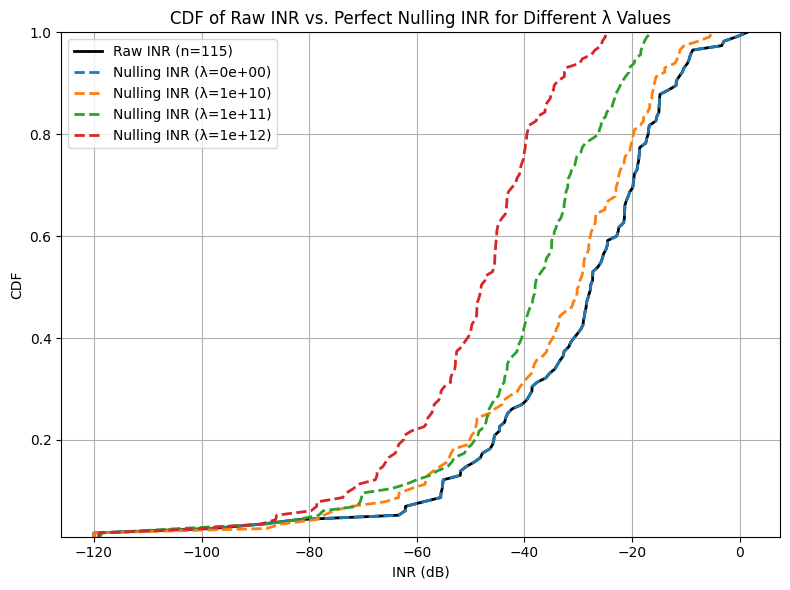

In [14]:
# Create a new figure
plt.figure(figsize=(8, 6))

# ------- Plot raw INR (no nulling) -------
inr_array = np.array(inr_list)
inr_array = inr_array[np.isfinite(inr_array)]
inr_sorted = np.sort(inr_array)
if len(inr_sorted) > 0:
    cdf_inr = np.arange(1, len(inr_sorted) + 1) / len(inr_sorted)
    plt.plot(inr_sorted, cdf_inr, label=f"Raw INR (n={len(inr_sorted)})", linewidth=2, color='black')

# ------- Plot INR Nulling for each lambda -------
for lambda_ in lambda_ranges:
    raw_inr_null_list = inr_nulling_dict[lambda_]
    inr_null_array = np.array(raw_inr_null_list)
    inr_null_array = inr_null_array[np.isfinite(inr_null_array)]
    inr_null_sorted = np.sort(inr_null_array)

    if len(inr_null_sorted) > 0:
        cdf_inr_null = np.arange(1, len(inr_null_sorted) + 1) / len(inr_null_sorted)
        plt.plot(inr_null_sorted, cdf_inr_null,
                #  label=f"Nulling INR (λ={lambda_:.0e}, n={len(inr_null_sorted)})",
                label=f"Nulling INR (λ={lambda_:.0e})",
                 linestyle="--", linewidth=2)

# ------- Make the plot pretty -------
plt.xlabel("INR (dB)")
plt.ylabel("CDF")
plt.title("CDF of Raw INR vs. Perfect Nulling INR for Different λ Values")
plt.grid(True)
plt.legend()
plt.ylim([0.01, 1])
plt.tight_layout()
plt.show()


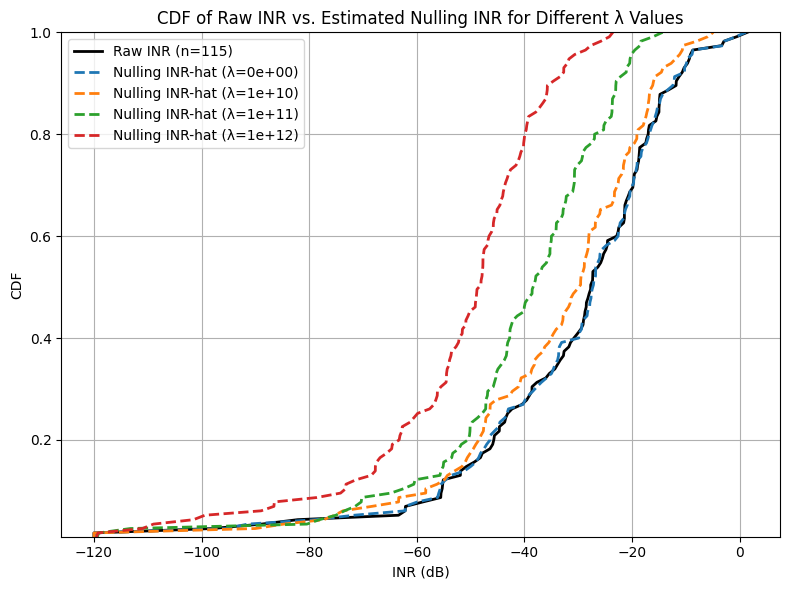

In [20]:
# Create a new figure
plt.figure(figsize=(8, 6))

# ------- Plot raw INR (no nulling) -------
inr_array = np.array(inr_list)
inr_array = inr_array[np.isfinite(inr_array)]
inr_sorted = np.sort(inr_array)
if len(inr_sorted) > 0:
    cdf_inr = np.arange(1, len(inr_sorted) + 1) / len(inr_sorted)
    plt.plot(inr_sorted, cdf_inr, label=f"Raw INR (n={len(inr_sorted)})", linewidth=2, color="black")

# ------- Plot INR Nulling (hat) for each lambda -------
for lambda_ in lambda_ranges:
    raw_inr_null_hat_list = inr_nulling_hat_dict[lambda_]
    inr_null_hat_array = np.array(raw_inr_null_hat_list)
    inr_null_hat_array = inr_null_hat_array[np.isfinite(inr_null_hat_array)]
    inr_null_hat_sorted = np.sort(inr_null_hat_array)

    if len(inr_null_hat_sorted) > 0:
        cdf_inr_null_hat = np.arange(1, len(inr_null_hat_sorted) + 1) / len(inr_null_hat_sorted)
        plt.plot(
            inr_null_hat_sorted,
            cdf_inr_null_hat,
            label=f"Nulling INR-hat (λ={lambda_:.0e})",
            linestyle="--",
            linewidth=2,
        )

# ------- Make the plot pretty -------
plt.xlabel("INR (dB)")
plt.ylabel("CDF")
plt.title("CDF of Raw INR vs. Estimated Nulling INR for Different λ Values")
plt.grid(True)
plt.legend()
plt.ylim([0.01, 1])
plt.tight_layout()
plt.show()


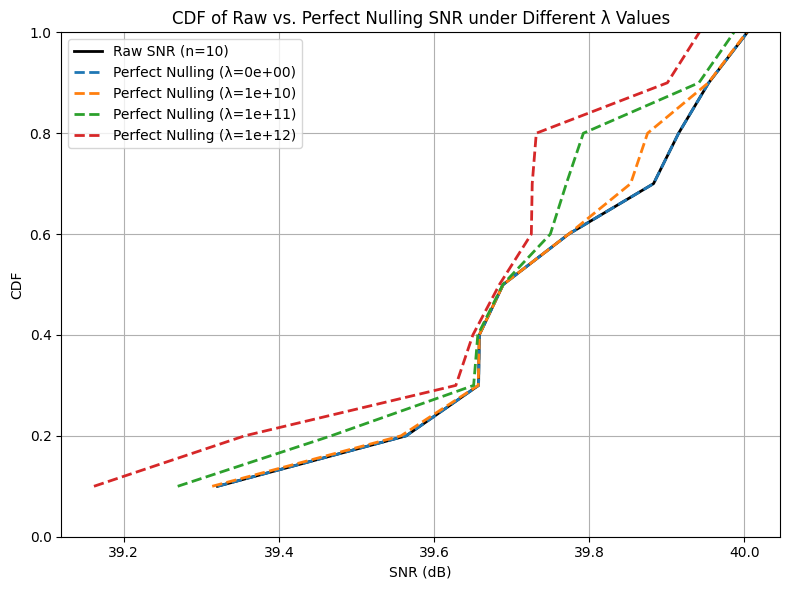

In [15]:
plt.figure(figsize=(8, 6))
# ------- Plot raw SNR (no nulling) -------
snr_array = np.array(snr_list)
snr_array = snr_array[np.isfinite(snr_array)]
snr_sorted = np.sort(snr_array)

if len(snr_sorted) > 0:
    cdf_snr = np.arange(1, len(snr_sorted) + 1) / len(snr_sorted)
    plt.plot(snr_sorted, cdf_snr, label=f"Raw SNR (n={len(snr_sorted)})", linewidth=2, color='black')

# ------- Plot Nulling SNR for each lambda -------
for lambda_ in lambda_ranges:
    # Ideal interference known
    snr_null = np.array(snr_nulling_dict[lambda_])
    snr_null = snr_null[np.isfinite(snr_null)]
    snr_null_sorted = np.sort(snr_null)

    if len(snr_null_sorted) > 0:
        cdf_snr_null = np.arange(1, len(snr_null_sorted) + 1) / len(snr_null_sorted)
        plt.plot(snr_null_sorted, cdf_snr_null,
                 label=f"Perfect Nulling (λ={lambda_:.0e})", linestyle='--', linewidth=2)


# ------- Make the plot nice -------
plt.xlabel("SNR (dB)")
plt.ylabel("CDF")
plt.title("CDF of Raw vs. Perfect Nulling SNR under Different λ Values")
plt.grid(True)
plt.legend()
plt.ylim([0, 1])
plt.tight_layout()
plt.show()


Different Satellite Angle

In [16]:
# CODEx_FIXED: radiomap render function (no npz required)
import mitsuba as mi
from sionna.rt import RadioMapSolver, Camera, Receiver
import numpy as np
import matplotlib.pyplot as plt

try:
    from sionna.rt import transform_mesh
except Exception:
    transform_mesh = None


def _get_terrain_mesh(scene, terrain_name="Terrain", z_offset=0.1):
    if hasattr(scene, "objects") and terrain_name in scene.objects:
        terrain = scene.objects[terrain_name].clone(as_mesh=True)
    else:
        terrain = None
        if hasattr(scene, "objects"):
            for name in scene.objects.keys():
                if "terrain" in name.lower() or "plane" in name.lower():
                    terrain = scene.objects[name].clone(as_mesh=True)
                    break
        if terrain is None:
            return None
    if transform_mesh is not None:
        transform_mesh(terrain, translation=[0, 0, z_offset])
    else:
        raise RuntimeError("transform_mesh not available in your sionna version")
    return terrain


def _build_precoding_from_record(scene, nsect, lambda_):
    if lambda_ not in v_null_record or len(v_null_record[lambda_]) == 0:
        raise ValueError(f"No v_null_record for lambda={lambda_}")

    t_to_v = {}
    for t, v in zip(v_null_t_index[lambda_], v_null_record[lambda_]):
        t = int(t)
        if t not in t_to_v:
            t_to_v[t] = np.asarray(v).reshape(-1).astype(np.complex64)

    tx_names = list(scene.transmitters)
    if len(tx_names) == 0:
        raise ValueError("scene.transmitters is empty. Run compute_paths first.")

    num_tx_ant = next(iter(t_to_v.values())).shape[0]
    precoding = np.zeros((len(tx_names), num_tx_ant), dtype=np.complex64)

    for i, name in enumerate(tx_names):
        if not name.startswith("tx-"):
            continue
        parts = name.split("-")
        if len(parts) != 3:
            continue
        try:
            bs_idx = int(parts[1])
            sec_idx = int(parts[2])
        except ValueError:
            continue
        t = bs_idx * nsect + sec_idx
        if t in t_to_v:
            precoding[i, :] = t_to_v[t]

    return precoding


def _cast_solver_seed(seed):
    if seed is None:
        return None
    for type_name in ("UInt", "UInt32", "UInt64"):
        t = getattr(mi, type_name, None)
        if t is not None:
            try:
                return t(int(seed))
            except Exception:
                pass
    try:
        import drjit as dr
        return dr.uint32(int(seed))
    except Exception:
        return int(seed)




def _patch_sampler_seed_compat(solver):
    """Patch sampler.seed to support both (seed) and (seed, wavefront_size)."""
    sampler = getattr(solver, "_sampler", None)
    if sampler is None:
        return
    cls = sampler.__class__
    if getattr(cls, "_codex_seed_patched", False):
        return

    orig_seed = getattr(cls, "seed", None)
    if orig_seed is None:
        return

    def seed_compat(self, seed, wavefront_size=4294967295):
        try:
            return orig_seed(self, seed, int(wavefront_size))
        except TypeError:
            return orig_seed(self, seed)

    try:
        cls.seed = seed_compat
        cls._codex_seed_patched = True
    except Exception:
        pass


def render_nulling_radiomap_all(scene, nsect, lambda_,
                                center=None, size=None, cell_size=(10, 10),
                                max_depth=3, samples_per_tx=2**18,
                                metric="inr_ntn",
                                show_scene=False,
                                show_2d=False,
                                use_terrain=True,
                                terrain_name="Terrain",
                                terrain_z_offset=1.5,
                                show_tn=False,
                                show_left_ntn=False,
                                show_legend=False,
                                legend_loc="upper right",
                                tn_color=(0.0, 0.35, 1.0),
                                left_ntn_color=(0.0, 1.0, 1.0),
                                tn_display_radius=120,
                                left_ntn_display_radius=90,
                                rm_vmin=None, rm_vmax=None,
                                camera_pos=[0, 0, 9000],
                                camera_look_at=[0, 0, 0],
                                render_resolution=(5000, 5000),
                                render_fov=95,
                                render_num_samples=16,
                                render_retry_on_oom=True,
                                seed=1,
                                precoding_matrix=None):

    for rx_name in list(scene.receivers):
        scene.remove(rx_name)

    tx_names = list(scene.transmitters)
    if len(tx_names) == 0:
        raise ValueError("scene.transmitters is empty. Run compute_paths first.")

    if precoding_matrix is not None:
        precoding = np.asarray(precoding_matrix, dtype=np.complex64)
        if precoding.ndim != 2:
            raise ValueError(f"precoding_matrix must be 2-D, got shape {precoding.shape}")
        if precoding.shape[0] != len(tx_names):
            raise ValueError(f"precoding_matrix row mismatch: got {precoding.shape[0]}, expected {len(tx_names)}")
    else:
        precoding = _build_precoding_from_record(scene, nsect, lambda_)

    nz = np.linalg.norm(precoding, axis=1) > 0
    print(f"TX total: {len(tx_names)}, with precoding: {np.count_nonzero(nz)}")
    if np.count_nonzero(nz) == 0:
        raise ValueError("All precoding vectors are zero.")

    precoding_vec = (
        mi.TensorXf(np.ascontiguousarray(precoding.real.astype(np.float32))),
        mi.TensorXf(np.ascontiguousarray(precoding.imag.astype(np.float32))),
    )

    rm_solver = RadioMapSolver()
    # Mitsuba sampler requires wavefront_size <= 2^32-1.
    num_tx = len(tx_names)
    max_wavefront = (2**32) - 1
    max_samples_per_tx = max(1, max_wavefront // max(1, num_tx))
    eff_samples_per_tx = int(min(int(samples_per_tx), int(max_samples_per_tx)))
    if eff_samples_per_tx != int(samples_per_tx):
        print(f"samples_per_tx clipped from {int(samples_per_tx)} to {eff_samples_per_tx} for {num_tx} TX")

    _patch_sampler_seed_compat(rm_solver)
    seed_cast = _cast_solver_seed(seed)

    measurement_surface = None
    if use_terrain:
        measurement_surface = _get_terrain_mesh(scene, terrain_name=terrain_name, z_offset=terrain_z_offset)

    if measurement_surface is not None:
        rm = rm_solver(scene,
                       measurement_surface=measurement_surface,
                       max_depth=max_depth,
                       samples_per_tx=eff_samples_per_tx,
                       precoding_vec=precoding_vec,
                       cell_size=cell_size,
                       seed=seed_cast)
    else:
        if center is not None:
            center = [float(center[0]), float(center[1]), float(center[2])]
        if size is not None:
            size = [float(size[0]), float(size[1])]

        rm = rm_solver(scene,
                       max_depth=max_depth,
                       samples_per_tx=eff_samples_per_tx,
                       precoding_vec=precoding_vec,
                       cell_size=cell_size,
                       center=center,
                       size=size,
                       orientation=[0, 0, 0],
                       seed=seed_cast)

    if show_scene:
        temp_names = []
        if show_tn and 'tn_pos' in globals():
            for i, pos in enumerate(tn_pos):
                name = f"tmp-tn-{i}"
                scene.add(Receiver(name=name, position=pos, color=tuple(tn_color), display_radius=tn_display_radius))
                temp_names.append(name)
        if show_left_ntn and 'left_ntn_pos' in globals() and left_ntn_pos is not None:
            for i, pos in enumerate(left_ntn_pos):
                name = f"tmp-leftntn-{i}"
                scene.add(Receiver(name=name, position=pos, color=tuple(left_ntn_color), display_radius=left_ntn_display_radius))
                temp_names.append(name)

        cam_dist = float(np.linalg.norm(np.asarray(camera_pos, dtype=float) - np.asarray(camera_look_at, dtype=float)))
        if cam_dist > 9800:
            print(f"warning: camera distance {cam_dist:.1f}m is close to/exceeds Sionna far_clip=10000; image may be blank")
        cam = Camera(position=list(camera_pos), look_at=list(camera_look_at))
        render_kwargs = dict(camera=cam,
                             radio_map=rm,
                             resolution=tuple(render_resolution),
                             fov=float(render_fov),
                             rm_show_color_bar=True,
                             rm_vmin=rm_vmin,
                             rm_vmax=rm_vmax,
                             rm_metric=metric,
                             num_samples=int(render_num_samples))
        try:
            scene.render(**render_kwargs)
        except RuntimeError as e:
            msg = str(e).lower()
            if (not render_retry_on_oom) or ("out of memory" not in msg):
                raise
            w, h = render_kwargs["resolution"]
            ns = int(render_kwargs["num_samples"])
            w2, h2 = max(1024, w//2), max(1024, h//2)
            ns2 = max(4, ns//2)
            print(f"render OOM: retry with resolution={(w2, h2)}, num_samples={ns2}")
            render_kwargs["resolution"] = (w2, h2)
            render_kwargs["num_samples"] = ns2
            scene.render(**render_kwargs)

        if show_legend:
            from matplotlib.lines import Line2D

            handles = [
                Line2D([0], [0], marker='o', linestyle='None', color='red',
                       markerfacecolor='red', markeredgecolor='red', markersize=8, label='BS')
            ]
            if show_tn:
                handles.append(
                    Line2D([0], [0], marker='o', linestyle='None', color=tuple(tn_color),
                           markerfacecolor=tuple(tn_color), markeredgecolor=tuple(tn_color),
                           markersize=8, label='TN')
                )
            if show_left_ntn:
                handles.append(
                    Line2D([0], [0], marker='o', linestyle='None', color=tuple(left_ntn_color),
                           markerfacecolor=tuple(left_ntn_color), markeredgecolor=tuple(left_ntn_color),
                           markersize=8, label='NTN')
                )

            try:
                fig = plt.gcf()
                ax = fig.axes[0] if len(fig.axes) > 0 else plt.gca()
                if legend_loc == 'upper left':
                    ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(0.02, 0.98),
                              borderaxespad=0.0, frameon=True)
                else:
                    ax.legend(handles=handles, loc=legend_loc, frameon=True)
                plt.show()
            except Exception:
                fig_leg, ax_leg = plt.subplots(figsize=(4.8, 0.8))
                ax_leg.axis('off')
                ax_leg.legend(handles=handles, loc='center', ncol=len(handles), frameon=True)
                plt.show()

        for name in temp_names:
            if name in scene.receivers:
                scene.remove(name)
                
    return rm






TX total: 12, with precoding: 10


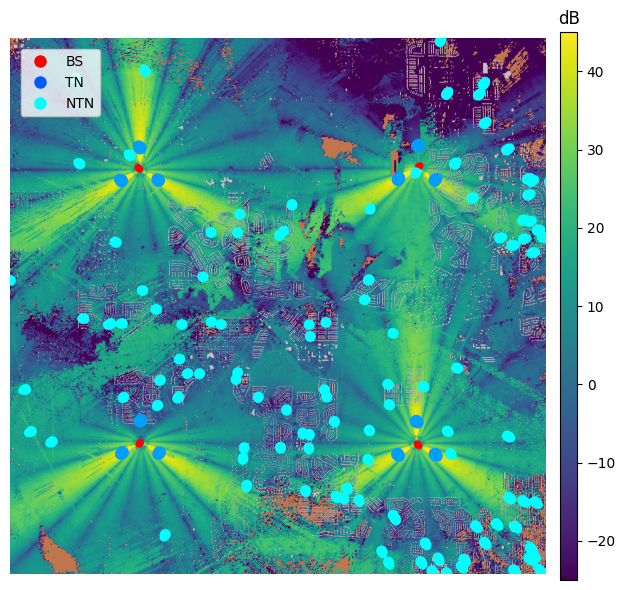

In [18]:
rm = render_nulling_radiomap_all(
    scene, nsect, lambda_=1e12,
    metric='inr_ntn',
    show_scene=True,
    show_legend=True,
    legend_loc='upper left',
    use_terrain=True,
    terrain_name="terrain",
    terrain_z_offset=2.5,
    cell_size=(1, 1),
    max_depth=3,
    samples_per_tx=10*10**7,
    show_tn=True,
    show_left_ntn=True,
    tn_display_radius=120,
    left_ntn_display_radius=100,
    camera_pos=[0, 0, 5000],
    camera_look_at=[0, 0, 0],
    render_resolution=(9000, 9000),
    render_fov=90,
    rm_vmin=-25,
    rm_vmax=45,
    seed=1
)


In [19]:
# scene.preview(
#     paths= SceneConfig.paths_ntn,
#     radio_map=rm,
#     rm_metric="inr_ntn",   # 或 "rss" / "sinr"
#     rm_vmin=-25,
#     rm_vmax=45
#     # rm_db_scale=True
# )